In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

import joblib

In [2]:
data = pd.read_csv("creditcard.csv")

data.head()
data.shape
data.info
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


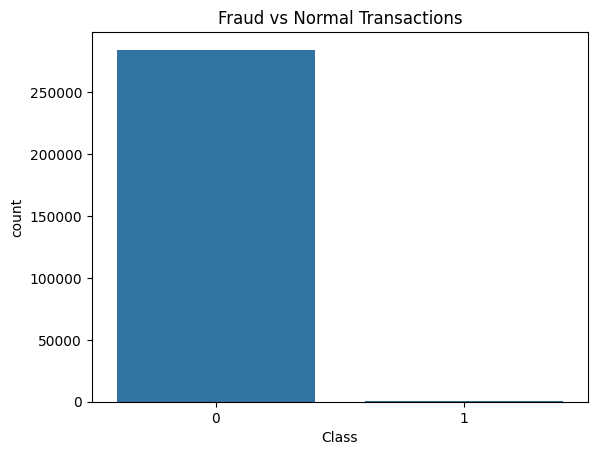

In [3]:
sns.countplot(x="Class", data=data)

plt.title("Fraud vs Normal Transactions")

plt.show()

In [4]:
X = data.drop("Class", axis=1)

y = data["Class"]

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [6]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print("Balanced classes:", np.bincount(y_resampled))

Balanced classes: [284315 284315]


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

In [8]:
input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))

In [9]:
encoded = Dense(32, activation="relu")(input_layer)

encoded = Dense(16, activation="relu")(encoded)

latent = Dense(8, activation="relu")(encoded)

In [10]:
decoded = Dense(16, activation="relu")(latent)

decoded = Dense(32, activation="relu")(decoded)

output = Dense(input_dim, activation="sigmoid")(decoded)

In [11]:
autoencoder = Model(input_layer, output)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,334 (13.02 KB)

 Trainable params: 3,334 (13.02 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
autoencoder.fit(
    X_train,
    X_train,
    epochs=10,
    batch_size=256,
    validation_split=0.2
)

Epoch 1/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - loss: 10.9728 - val_loss: 10.7852
Epoch 2/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 10.8759 - val_loss: 10.7590
Epoch 3/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 10.8402 - val_loss: 10.7209
Epoch 4/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 10.8210 - val_loss: 10.7092
Epoch 5/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 10.8119 - val_loss: 10.7015
Epoch 6/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 10.8062 - val_loss: 10.6977
Epoch 7/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 10.7998 - val_loss: 10.6904
Epoch 8/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 10.7959 - val_loss: 10.6881
Epoch 9/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 10.7882 - val_loss: 10.6741
Epoch 10/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - loss: 10.7793 - val_loss: 10.6713


In [13]:
encoder = Model(input_layer, latent)

X_train_encoded = encoder.predict(X_train)

X_test_encoded = encoder.predict(X_test)

14216/14216 ━━━━━━━━━━━━━━━━━━━━ 58s 4ms/step
3554/3554 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step


In [14]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_encoded, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
pred = rf_model.predict(X_test_encoded)

In [16]:
confusion_matrix(y_test, pred)

array([[56690,    60],
       [   57, 56919]])

In [17]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



In [19]:
roc_auc_score(y_test, prob)

0.9999636641194932

In [20]:
joblib.dump(rf_model, "fraud_model.pkl")

joblib.dump(scaler, "scaler.pkl")

joblib.dump(encoder, "encoder_model.pkl")

print("Models saved successfully")

Models saved successfully


In [21]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Load dataset
data = pd.read_csv("creditcard.csv")

# Select only 3 features
X = data[["Time", "Amount"]]

# Create frequency feature
X["freq"] = 1

y = data["Class"]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train model
rf_model = RandomForestClassifier(n_estimators=200)

rf_model.fit(X_train, y_train)

# Save model
joblib.dump(rf_model, "fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved")

C:\hadoop\tmp\ipykernel_10204\3318179826.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["freq"] = 1


Model saved
